In [1]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Soybeans Futures Historical Data.csv'].decode('utf-8')), index_col='Date', parse_dates=True)

Saving US Soybeans Futures Historical Data.csv to US Soybeans Futures Historical Data (1).csv


In [4]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.

In [5]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-5-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


<Axes: xlabel='Date'>

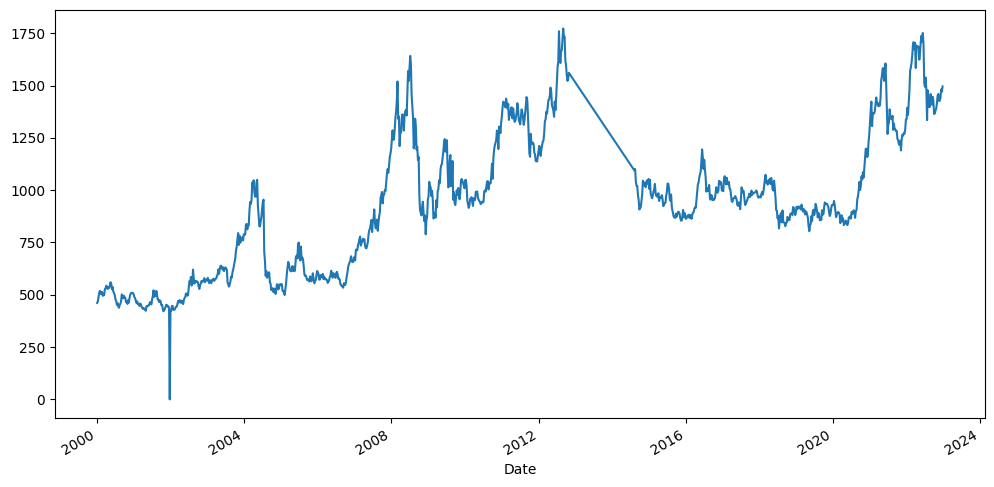

In [6]:
data["Open"].plot(figsize=(12,6))

In [7]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [8]:
ad_test(data['Price'])

1. ADF:  -2.31363348533143
2. p-value:  0.16760859540306816
3. No. of lags:  12
4. No. of observations used for ADF Regression and Critical Values Calculations:  1072
5. Critical Values: 
	 1% , -3.4364647646486093
	 5% , -2.864239892228526
	 10% , -2.5682075189699822


In [9]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [10]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11128.629, Time=3.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11146.970, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11136.407, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11138.789, Time=1.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11145.569, Time=0.21 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=11126.674, Time=2.65 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=11124.685, Time=1.13 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=11126.676, Time=2.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=11129.350, Time=4.96 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=11128.431, Time=3.67 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=11123.269, Time=0.60 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=11137.507, Time=0.40 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=11125.262, Time=1.09 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=11125.263, Time=0.75 sec
 ARIMA(1,1,1)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1085
Model:               SARIMAX(0, 1, 2)   Log Likelihood               -5558.635
Date:                Sun, 28 May 2023   AIC                          11123.269
Time:                        05:11:24   BIC                          11138.234
Sample:                             0   HQIC                         11128.935
                               - 1085                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0961      0.016     -6.191      0.000      -0.126      -0.066
ma.L2          0.1231      0.018      6.855      0.000       0.088       0.158
sigma2      1665.4719     28.829     57.770      0.000    1608.967    1721.977
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             17410.05
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.56   Skew:                             1.85
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [12]:
num_rows = data.shape[0]
print("Number of rows:", num_rows)

Number of rows: 1085


In [13]:
import statsmodels.api as sm

In [14]:
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-22]
test=data.iloc[-22:]
print(train.shape, test.shape)

(1085, 5)
(1063, 5) (22, 5)


In [15]:
# Taining the model
model=sm.tsa.arima.ARIMA(train['Price'], order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 1063
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -5459.634
Date:                Sun, 28 May 2023   AIC                          10935.267
Time:                        05:11:30   BIC                          10975.018
Sample:                             0   HQIC                         10950.331
                               - 1063                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        933.9782    207.320      4.505      0.000     527.638    1340.318
ar.L1          0.9929      0.005    203.065      0.000       0.983       1.003
ma.L1         -0.0895      0.017     -5.236      0.000      -0.123      -0.056
ma.L2          0.1330      0.019      6.955      0.000       0.096       0.170
ma.L3         -0.0039      0.019     -0.203      0.839      -0.042       0.034
ma.L4          0.0132      0.022      0.600      0.549      -0.030       0.056
ma.L5         -0.0471      0.021     -2.260      0.024      -0.088      -0.006
sigma2      1686.1000     31.480     53.561      0.000    1624.400    1747.800
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             16959.45
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.56   Skew:                             1.95
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
# Make predictions on the Test dataset
start = len(train)
end = len(train) + len(test)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

1063    523.185909
1064    527.786510
1065    529.891039
1066    532.632704
1067    534.944627
1068    537.769030
1069    540.573441
1070    543.358002
1071    546.122853
1072    548.868135
1073    551.593985
1074    554.300541
1075    556.987940
1076    559.656318
1077    562.305808
1078    564.936545
1079    567.548661
1080    570.142289
1081    572.717558
1082    575.274600
1083    577.813542
1084    580.334514
Name: predicted_mean, dtype: float64
Date
2000-05-28    523.185909
2000-05-21    527.786510
2000-05-14    529.891039
2000-05-07    532.632704
2000-04-30    534.944627
2000-04-23    537.769030
2000-04-16    540.573441
2000-04-09    543.358002
2000-04-02    546.122853
2000-03-26    548.868135
2000-03-19    551.593985
2000-03-12    554.300541
2000-03-05    556.987940
2000-02-27    559.656318
2000-02-20    562.305808
2000-02-13    564.936545
2000-02-06    567.548661
2000-01-30    570.142289
2000-01-23    572.717558
2000-01-16    575.274600
2000-01-09    577.813542
2000-01-02    5

<Axes: xlabel='Date'>

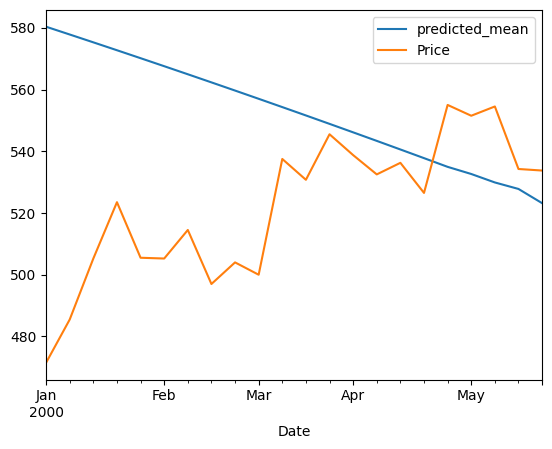

In [17]:
# Plotting the predicted values and the test set
pred.plot(legend=True)
test['Price'].plot(legend=True)

In [18]:
test['Price'].mean()

522.2159090909091

In [19]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test['Price'], pred))
print(rmse)

48.36858051376908
